In [1]:
import anndata as ad
import pandas as pd
import numpy as np
import random
import scanpy as sc
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from wompywompy import plot_alluvial
from statsmodels.stats.multitest import multipletests
from upsetplot import UpSet, from_memberships
from itertools import chain
from ember_py.plots import plot_partition_specificity, plot_block_specificity, plot_sample_counts, plot_psi_blocks
plt.style.use('default')  

In [2]:
# replace this path with the path for where the downloaded supplement file is located
supplement_file_path = "/home/nikki/Supplementary_data/"

# replace this path with output path
output_path = "/home/nikki/swarna2025_figs/figs/fig3/"

# Fig1

## a

/home/nikki/miniconda3/envs/swarna2025_env/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/nikki/miniconda3/envs/swarna2025_env/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.

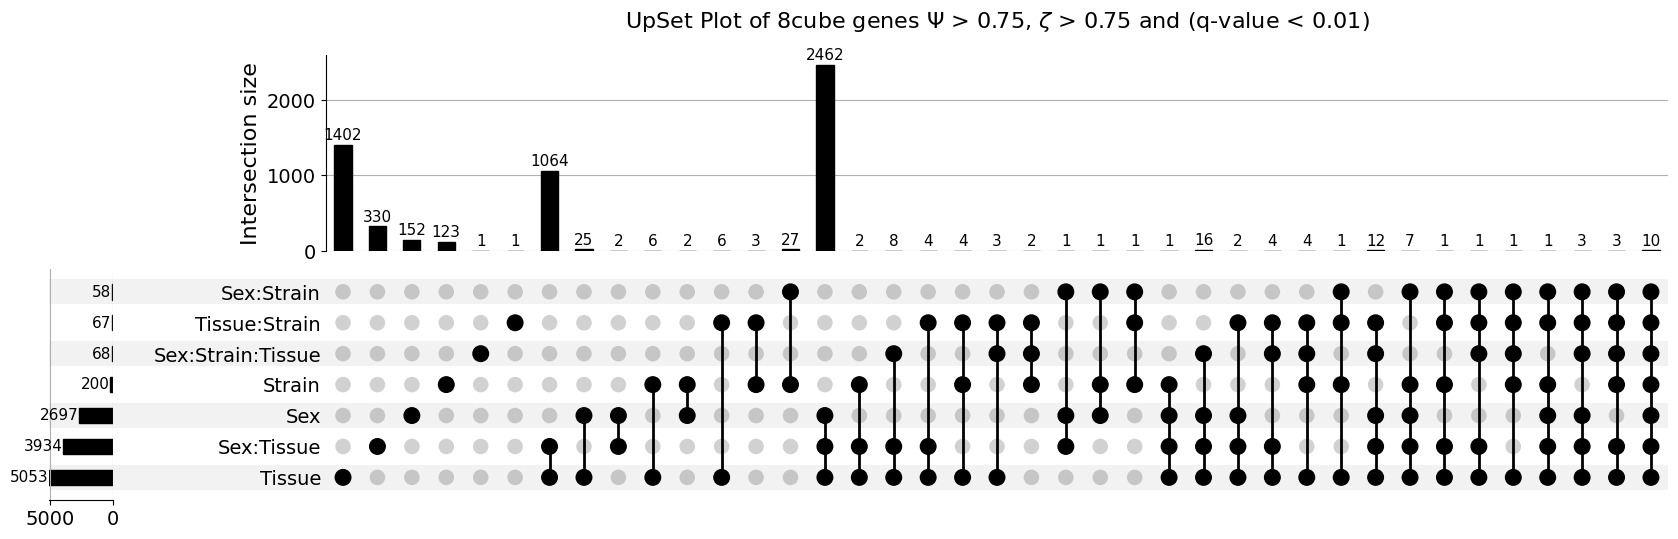

In [16]:
# Define variables
partition_list = ['Sex', 'Tissue', 'Strain',
                  'Sex:Tissue', 'Sex:Strain', 'Tissue:Strain',
                  'Sex:Strain:Tissue']
fdr_thresh = 0.01
psi_thresh = 0.75
zeta_thresh = 0.75

# Read all DataFrames and label them by partition
dfs = []
for partition in partition_list:
    pvals_path = os.path.join(supplement_file_path, f"8cube_across_tissues/{partition}.csv")
    df = pd.read_csv(pvals_path)
    df['partition'] = partition
    dfs.append(df)

# Combine all data for global FDR correction
combined_df = pd.concat(dfs, ignore_index=True)

# Global FDR correction for both Psi and Zeta
_, combined_df['Psi FDR'], _, _ = multipletests(combined_df['Psi p-value'], method='fdr_bh')
_, combined_df['Zeta FDR'], _, _ = multipletests(combined_df['Zeta p-value'], method='fdr_bh')

# Filter for genes significant in both Psi and Zeta, and with effect sizes > 0.5
significant = combined_df[
    (combined_df['Psi FDR'] <= fdr_thresh) &
    (combined_df['Zeta FDR'] <= fdr_thresh) &
    (combined_df['Psi'] > psi_thresh) &
    (combined_df['Zeta'] > zeta_thresh)
]


# Create sets of significant genes per partition, ensuring no duplicates
partition_gene_sets = {
    partition: set(
        significant[significant['partition'] == partition]['gene_name']
    )
    for partition in partition_list
}


all_genes = set(chain.from_iterable(partition_gene_sets.values()))
memberships = []

for gene in all_genes:
    gene_membership = [
        partition for partition, gene_set in partition_gene_sets.items() if gene in gene_set
    ]
    memberships.append(gene_membership)
    
# Create UpSet data and plot
# Set larger font sizes globally
plt.rcParams.update({
    'font.size': 11,          # base font size
    'axes.titlesize': 16,     # title size
    'axes.labelsize': 16,     # axis label size
    'xtick.labelsize': 14,    # x-axis tick labels
    'ytick.labelsize': 14,    # y-axis tick labels
    'legend.fontsize': 14     # legend (if any)
})

upset_data = from_memberships(memberships)

# Create the UpSet plot
UpSet(
    upset_data,
    subset_size='count',
    show_counts=True,
    sort_by='degree',
).plot()

# Title and layout
plt.title(
    fr'UpSet Plot of 8cube genes $\Psi$ > {psi_thresh}, $\zeta$ > {zeta_thresh} and (q-value < {fdr_thresh})',
    pad=20
)
plt.tight_layout()
out_fig_path = os.path.join(output_path, "upset_across_tissues.png")
plt.savefig(out_fig_path)
plt.show()

## b

In [17]:
pseudobulk_path = os.path.join(supplement_file_path, "PCA_pseudobulk_expression_matrix_across_tissues_strain.csv")
pseudobulk = pd.read_csv(pseudobulk_path, index_col = 0)

In [18]:
# Perform PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(pseudobulk.T)

meta = pseudobulk.columns.str.extract(r'(?P<Tissue>.+)_(?P<Genotype>.+)')
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['Genotype'] = meta['Genotype'].values
pca_df['Tissue'] = meta['Tissue'].values
pca_df = pca_df.rename(columns={
    'Genotype': 'Strain'
})

#color scheme
mice_strains = {
    "129S1J": "#E69F00",
    "NODJ": "#56B4E9",
    "NZOJ": "#009E73",
    "B6J": "#F0E442",
    "AJ": "#0072B2",
    "CASTJ": "#D55E00",
    "PWKJ": "#CC79A7",
    "WSBJ": "#999999"
}


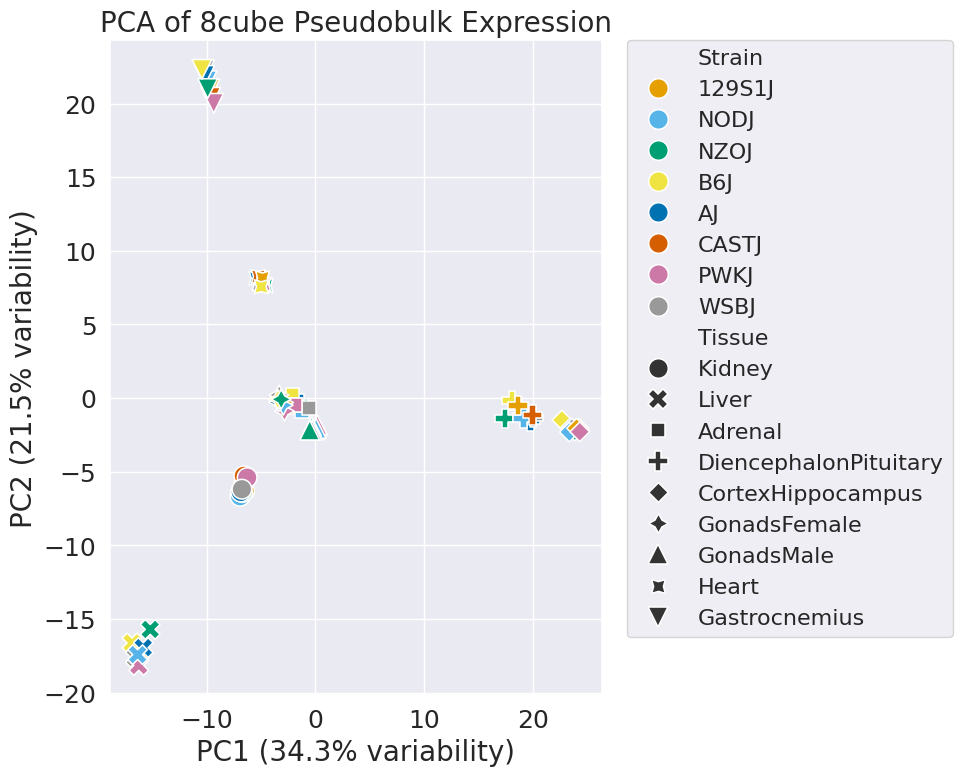

In [19]:
fontsize = 20
plt.figure(figsize=(10,8))
sns.set(context='notebook', font_scale=1.2)

sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='Strain', style='Tissue',
    s=200, 
    palette=mice_strains
)


plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variability)', fontsize=fontsize)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variability)', fontsize=fontsize)
plt.title("PCA of 8cube Pseudobulk Expression", fontsize=fontsize)

# tick labels fontsize = fontsize-2
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)

# Legend outside
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    fontsize=fontsize-4, 
    markerscale=1
)

plt.tight_layout()
out_fig_path = os.path.join(output_path, "pca_strain_tissue.png")
plt.savefig(out_fig_path)
plt.show()

## c and d

In [ ]:
genes = ["Cyp4a14", "Spink6"]
for gene_name in genes:
    plt.style.use('default') 
    pvals_path = os.path.join(supplement_file_path, f"8cube_across_tissues/{gene_name}_pseudobulk_wompwomp.csv")
    df = pd.read_csv(pvals_path)

    # cleaning out empty levels to improve effeciency
    df = df[df['umi_total'] > 0]
    df = df[['Sex', 'Genotype', 'Tissue', 'umi_total']]
    df = df.rename(columns={
        'Genotype': 'Strain'
    })
    df = df.groupby(['Sex', 'Strain', 'Tissue']).agg('sum').reset_index()

    color_dict = {
        "129S1J": "#E69F00",   # orange
        "NODJ": "#56B4E9",     # sky blue
        "NZOJ": "#009E73",     # green
        "B6J": "#F0E442",      # yellow
        "AJ": "#0072B2",       # deep blue
        "CASTJ": "#D55E00",    # vermillion
        "PWKJ": "#CC79A7",     # purple-pink
        "WSBJ": "#999999",      # gray
        "Male": "#762A83",   # violet
        "Female": "#1B7837",      # dark green
        "Gastrocnemius": "#8DD3C7",        # turquoise
        "Adrenal": "#FFFFB3",               # light yellow
        "Kidney": "#BEBADA",              # lavender
        "Liver": "#FB8072",                # coral
        "DiencephalonPituitary": "#80B1D3",# steel blue
        "CortexHippocampus": "#FDB462",           # peach
        "GOnadsMale": "#B3DE69",    # lime green
        "GonadsFemale": "#FCCDE5"          # pink

    }
    fig, order_dict = plot_alluvial(df, #pandas data frame  
                      # general function arguments
                      graphing_columns = ['Strain','Sex', 'Tissue'],optimize_column_order = False, column_weights = 'umi_total',
                                    color_alluvium = False, match_colors = False, verbose = True,
                                    sorting_algorithm = 'neighbornet', return_order_dict = True, color_dict = color_dict,
                                    save_height=12, save_width=9, default_text_size=25, alluvial_alpha=0.3,resolution=30)
    fig_out_path = os.path.join(output_path, f"{gene_name}_alluvial.png")
    fig[0].savefig(fig_out_path)

Sorting Data with sorting algorithm = neighbornet
Sorting Distance matrix with algorithm neighbornet
Determining Optimal Cycle Start
neighbornet_objective for iteration 0 = 11211327705882460
neighbornet_objective for iteration 1 = 10128443722359944
neighbornet_objective for iteration 2 = 8457039669535262
neighbornet_objective for iteration 3 = 10492849801746544
neighbornet_objective for iteration 4 = 8486847223489299
neighbornet_objective for iteration 5 = 8498019947427078
neighbornet_objective for iteration 6 = 7370381351755274
neighbornet_objective for iteration 7 = 7372099208596160
neighbornet_objective for iteration 8 = 7263760889953010
neighbornet_objective for iteration 9 = 7265389673939783


## e

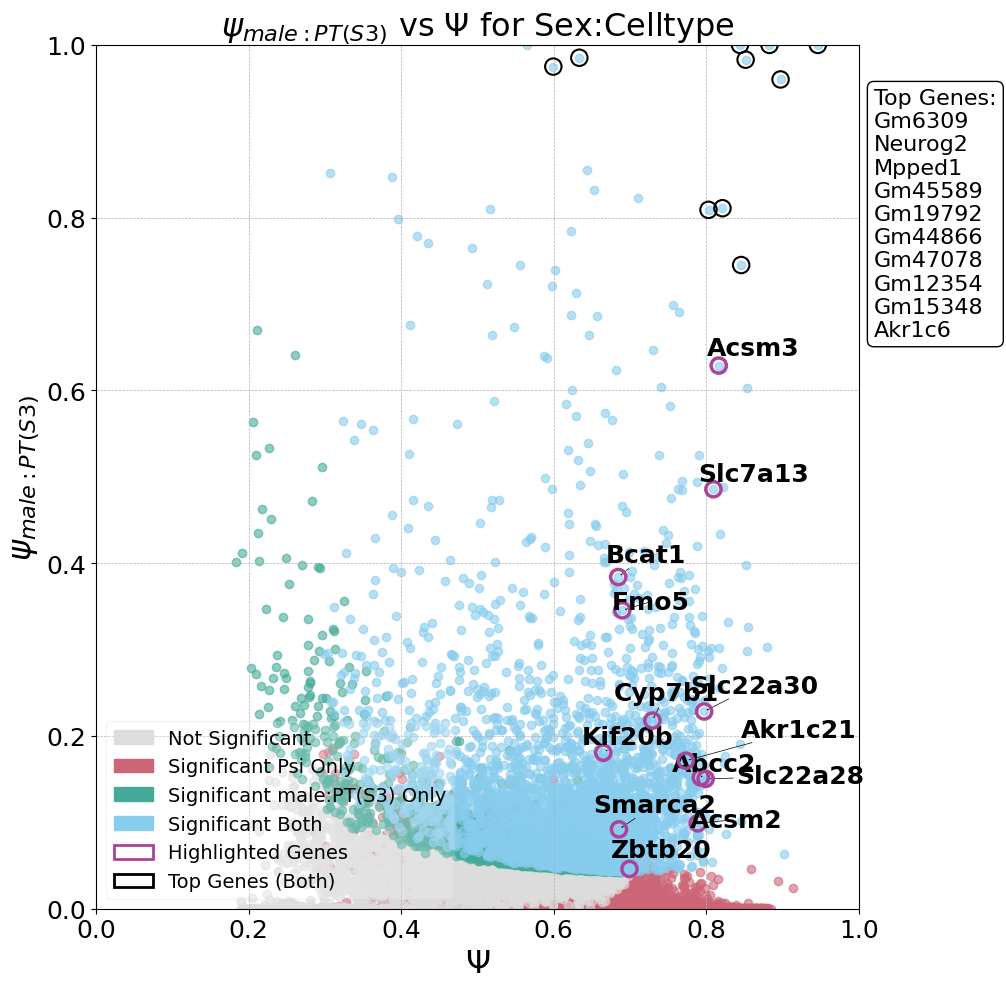

Block specificity plot saved to /home/nikki/swarna2025_figs/figs/fig3/block_specificity_scatterplot_Sex:Celltype_male:PT(S3).png


In [3]:
plt.style.use('default') 
pvals_path = os.path.join(supplement_file_path, 
                          'Developmental_kidney/psi_block_Sex:celltype_male:PT(S3).csv')
plot_block_specificity(partition_label = 'Sex:Celltype', 
                       block_label = 'male:PT(S3)',
                       pvals_dir = pvals_path, 
                       save_dir = output_path, 
                       highlight_genes=['Bcat1', 'Smarca2', 'Kif20b', 'Acsm3', 'Cyp7b1', 'Abcc2', 'Slc22a30', 'Fmo5', 'Zbtb20', 'Akr1c21', 'Slc7a13', 'Nrgl', 'Acsm2', 'Slc22a28'],
                       fontsize=20)


## f

In [22]:
subset_adata_path = os.path.join(supplement_file_path, "Developmental_kidney/Dev_kidney_fig_2_3_genes.h5ad")
subset_adata = ad.read_h5ad(subset_adata_path)

In [23]:
# Create the dictionary
ensembl_to_symbol = dict(zip(subset_adata.var.index, subset_adata.var["gene_symbols"]))
symbol_to_ensembl = {v: k for k, v in ensembl_to_symbol.items()}

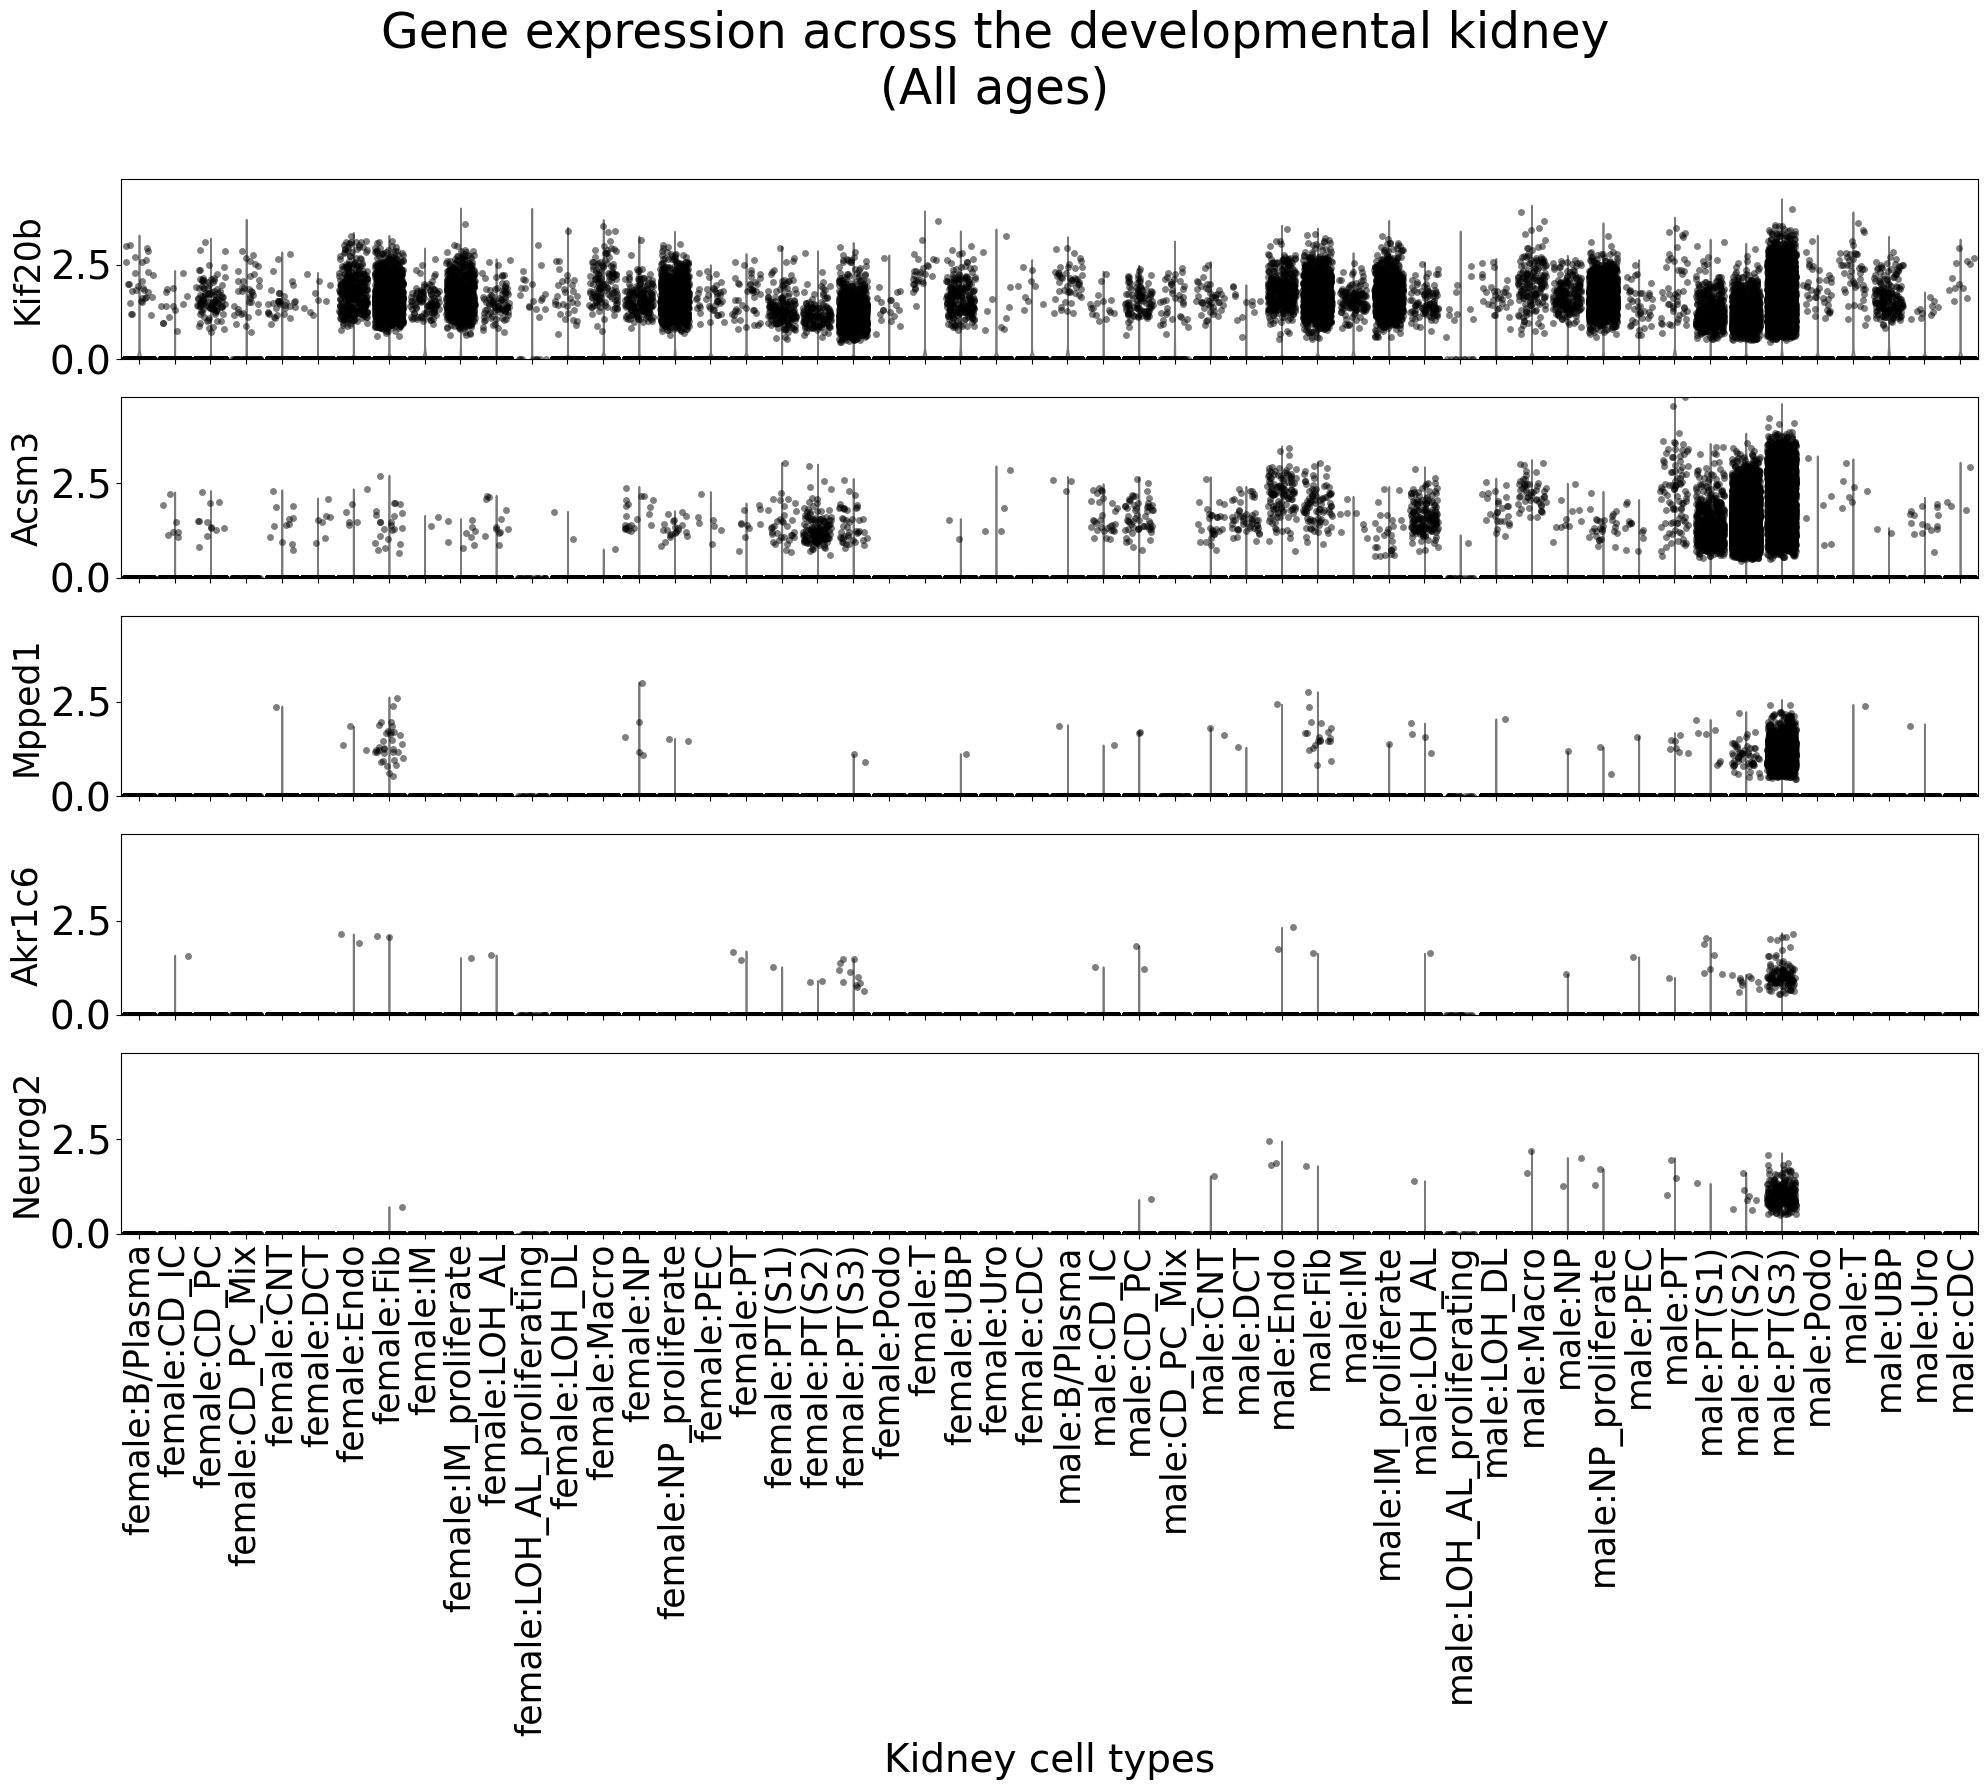

In [26]:
plt.style.use('default') 
genes_to_plot = ["Kif20b", "Acsm3", "Mpped1", "Akr1c6", "Neurog2" ]
fontsize = 25

# Build dataframe
dfs = []
for gene in genes_to_plot:
    ensg = symbol_to_ensembl[gene]
    expr = subset_adata[:, ensg].X
    expr = expr.toarray().flatten() if hasattr(expr, "toarray") else expr.flatten()
    
    df = pd.DataFrame({
        "expression": expr,
        "Age": subset_adata.obs["sex:celltype_final"].values,
        "Gene": gene
    })
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Global y-axis limits
ymax = df_all["expression"].max()


# Create stacked subplots
fig, axes = plt.subplots(len(genes_to_plot), 1, figsize=(20, 3.5*len(genes_to_plot)), sharey=True, sharex = True)

# Figure-wide title
fig.suptitle("Gene expression across the developmental kidney\n(All ages)", fontsize=fontsize+10, y = 1.02)

if len(genes_to_plot) == 1:
    axes = [axes]

for ax, gene in zip(axes, genes_to_plot):
    df_gene = df_all[df_all["Gene"] == gene]
    sns.violinplot(
        data=df_gene,
        x="Age", y="expression",
        color='lightblue',
        inner=None,
        ax=ax
    )
    sns.stripplot(
        data=df_gene,
        x="Age", y="expression",
        color="black", jitter=0.4, alpha=0.5,
        ax=ax
    )
    ax.set_ylabel(gene, fontsize=fontsize)
    ax.set_xlabel("Kidney cell types", fontsize = fontsize +3)
    ax.set_ylim(0, ymax)
    ax.tick_params(axis="x", rotation=90, labelsize=fontsize)
    ax.tick_params(axis="y", labelsize=fontsize+3)

plt.tight_layout()

fig_out_path = os.path.join(output_path, "dev_violin_sex:celltype.png")
plt.savefig(fig_out_path)
plt.show()